/var/folders/yf/z8cyz0qn4r557bdjflrksgkw0000gn/T/ipykernel_50553/1277736165.py:7: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv(BASE_DATA + 'order_items.csv')


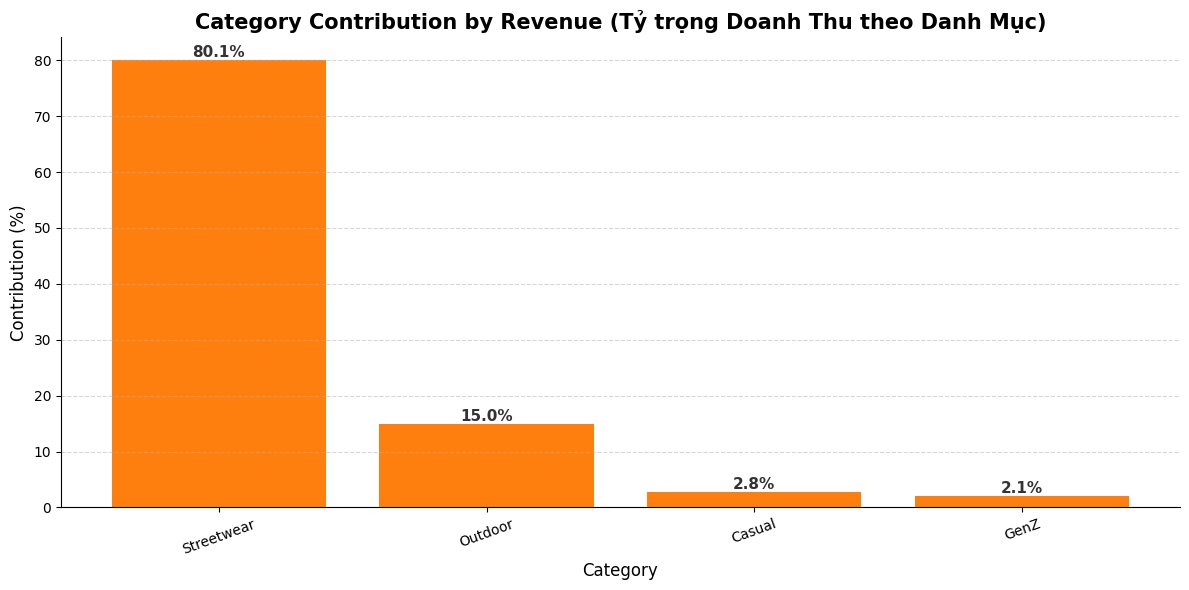

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Đọc dữ liệu
BASE_DATA = "data/"
products = pd.read_csv(BASE_DATA + 'products.csv')
order_items = pd.read_csv(BASE_DATA + 'order_items.csv')

# 2. Merge dữ liệu để lấy category cho từng item dựa vào product_id
order_items_merged = order_items.merge(products[['product_id', 'category']], on='product_id', how='inner')

# 3. Tính doanh thu (Revenue) cho mỗi sản phẩm bán ra
order_items_merged['revenue'] = (order_items_merged['quantity'] * order_items_merged['unit_price']) - order_items_merged['discount_amount'].fillna(0)

# 4. Gom nhóm tính tổng doanh thu theo Category 
category_revenue = order_items_merged.groupby('category')['revenue'].sum().sort_values(ascending=False)

# 5. Phân tích tỷ trọng phần trăm (Contribution)
total_revenue = category_revenue.sum()
category_percentage = (category_revenue / total_revenue) * 100

# ==========================================
# Vẽ biểu đồ Bar Chart Percentage
# ==========================================
plt.figure(figsize=(12, 6))
bars = plt.bar(category_percentage.index, category_percentage.values, color='#ff7f0e')

# Thêm số % lên đầu mỗi cột
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval:.1f}%', ha='center', fontsize=11, fontweight='bold', color='#333333')

plt.title('Category Contribution by Revenue (Tỷ trọng Doanh Thu theo Danh Mục)', fontsize=15, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Contribution (%)', fontsize=12)
plt.xticks(rotation=20)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Bỏ viền thừa của biểu đồ cho thiết kế thanh thoát hơn
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


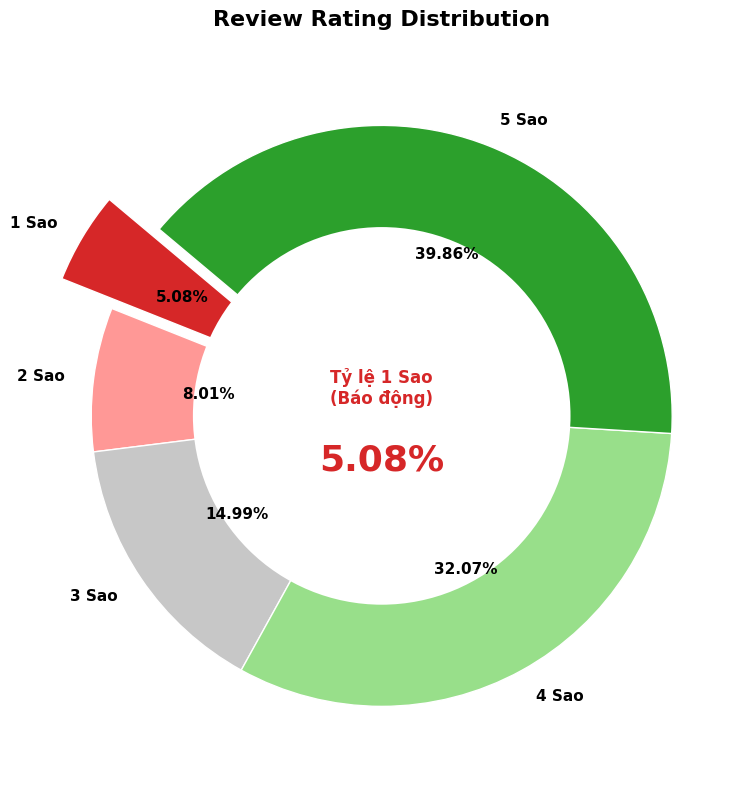

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Đọc dữ liệu đánh giá
BASE_DATA = "data/"
reviews = pd.read_csv(BASE_DATA + 'reviews.csv')

# 2. Đếm số lượng theo giá trị rating (từ 1 đến 5 sao)
rating_counts = reviews['rating'].value_counts()
total_reviews = len(reviews)

# Chuẩn hóa thứ tự index từ 1 đến 5 sao (với mapping string)
mapping = {1: '1 Sao', 2: '2 Sao', 3: '3 Sao', 4: '4 Sao', 5: '5 Sao'}
rating_counts.index = rating_counts.index.map(mapping)
rating_counts = rating_counts.reindex(['1 Sao', '2 Sao', '3 Sao', '4 Sao', '5 Sao']).fillna(0)

# 3. Tính % tỷ lệ phân bổ của các sao
percentage = rating_counts / total_reviews

# ==========================================
# Vẽ biểu đồ Donut Chart (Highlight 1 Sao bị vỡ ra khỏi bánh)
# ==========================================
# Set màu: Trắng/đỏ để nhấn mạnh sự tiêu cực của 1 sao, các review cao dần thì xanh lá
colors = ['#d62728', '#ff9896', '#c7c7c7', '#98df8a', '#2ca02c'] 
explode = (0.2, 0, 0, 0, 0)  # Tách lát cắt 1 sao (index 0) ra khỏi bánh

plt.figure(figsize=(8, 8))
plt.pie(percentage, explode=explode, labels=percentage.index, colors=colors, 
        autopct='%1.2f%%', startangle=140, textprops={'fontsize': 11, 'weight': 'bold'},
        wedgeprops=dict(edgecolor='w'))

# Thêm vòng tròn trắng ở giữa để tạo thành Donut chart đương đại
centre_circle = plt.Circle((0,0), 0.65, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# In số liệu đúc kết của phần 1 Sao ngay ở giữa tâm chart!
one_star_pct = percentage.get('1 Sao', 0)
plt.text(0, 0.1, 'Tỷ lệ 1 Sao\n(Báo động)', ha='center', va='center', fontsize=12, color='#d62728', fontweight='bold')
plt.text(0, -0.15, f'{one_star_pct:.2%}', ha='center', va='center', fontsize=26, color='#d62728', fontweight='bold')

plt.title('Review Rating Distribution', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()
